In [2]:
import numpy as np
import struct
import matplotlib.pyplot as plt
import os
from PIL import Image
from PIL import ImageFilter
import random
from tqdm import tqdm

In [3]:
images_filename = "train-images.idx3-ubyte"
labels_filename = "train-labels.idx1-ubyte"

In [4]:
def load_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [5]:
images = load_images(images_filename)
labels = load_labels(labels_filename)

In [6]:
def show_image(image, label):
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()
def show_random_image(images, labels):
    index = np.random.randint(0, len(images))
    show_image(images[index, :, :], labels[index])

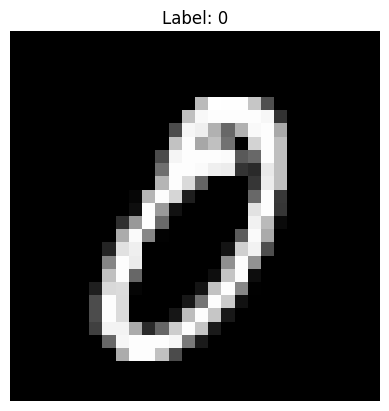

In [7]:
show_random_image(images, labels)

In [8]:
def rescale_images(images, target_size=(16, 16)):
    N = images.shape[0]
    resized = np.zeros((N, target_size[1], target_size[0]), dtype=images.dtype)

    for i in range(N):
        # Convert to PIL image, resize, convert back
        img = Image.fromarray(images[i])
        img = img.resize(target_size, Image.LANCZOS)
        resized[i] = np.array(img)

    return resized

In [9]:
def clip_grays(images, threshold=0.5):
    images = np.clip(images, 0, 255)
    images = (images > threshold * 255).astype(np.uint8) * 255
    return images

In [10]:
clipped_images = clip_grays(images, threshold=0.5)

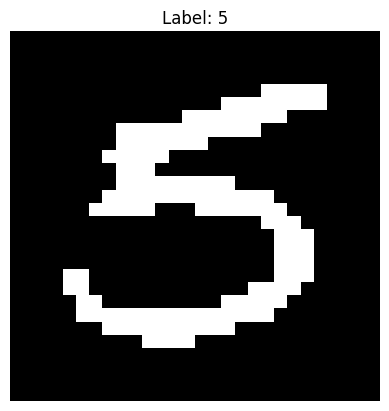

In [11]:
show_random_image(clipped_images, labels)

In [12]:
scaled_images = rescale_images(clipped_images, target_size=(16, 16))

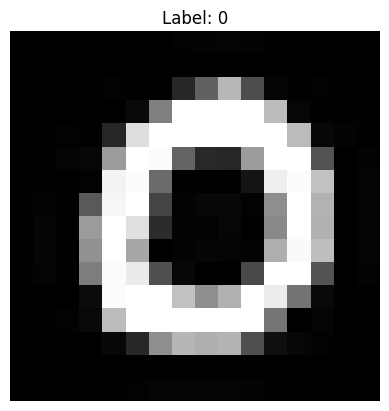

In [13]:
show_random_image(scaled_images, labels)

In [14]:
scaled_clipped_images = clip_grays(scaled_images, threshold=0.2)

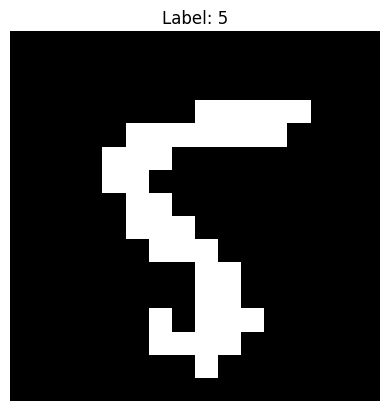

In [15]:
show_random_image(scaled_clipped_images, labels)

In [16]:
np.savez_compressed("mnist_augmented3.npz", images=scaled_clipped_images, labels=labels)

In [46]:
better_images = clip_grays(rescale_images(images, target_size=(16, 16)), threshold=0.4)

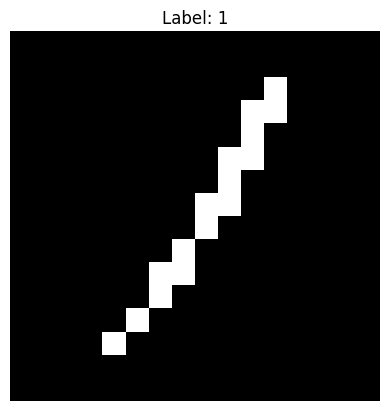

In [78]:
show_random_image(better_images, labels)

In [79]:
np.savez_compressed("mnist_augmented4.npz", images=better_images, labels=labels)